### Step 1: Mount the Google Drive

Remember to use GPU runtime before mounting your Google Drive. (Runtime --> Change runtime type).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### Step 2: Open the project directory

Replace `Your_Dir` with your own path.

In [ ]:
cd Your_Dir/emg2qwerty

### Step 3: Install required packages

After installing them, Colab will require you to restart the session.

In [ ]:
!pip install -r requirements.txt

### Step 4: Start your experiments!

- Remember to download and copy the dataset to this directory: `Your_Dir/emg2qwerty/data`.
- You may now start your experiments with any scripts! Below are examples of single-user training and testing (greedy decoding).
- **There are two ways to track the logs:**
  - 1. Keep `--multirun`, and the logs will not be printed here, but they will be saved in the folder `logs`, e.g., `logs/2025-02-09/18-24-15/submitit_logs/`.
  - 2. Comment out `--multirun` and the logs will be printed in this notebook, but they will not be saved.

# RUN THIS BEFORE TRAINING

In [2]:
import os
os.environ["TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD"] = "1"

## Baseline

#### Training baseline:

- The checkpoints are saved in the folder `logs`, e.g., `logs/2025-02-09/18-24-15/checkpoints/`.

In [ ]:
# Check the files are imported from the correct location (not from a different installation)
import emg2qwerty
import emg2qwerty.lightning as L
import emg2qwerty.data as D

print("emg2qwerty package:", emg2qwerty.__file__)
print("lightning.py:", L.__file__)
print("data.py:", D.__file__)

In [ ]:
# Single-user training
!python -m emg2qwerty.train \
  user="single_user" \
  trainer.accelerator=gpu trainer.devices=1 \
  trainer.max_epochs=40 \
  --multirun

#### Testing baseline:

- Replace `Your_Path_to_Checkpoint` with your checkpoint path.

In [ ]:
# Single-user testing
!python -m emg2qwerty.train \
  user="single_user" \
  checkpoint="Your_Path_to_Checkpoint" \
  train=False trainer.accelerator=gpu \
  decoder=ctc_greedy \
  hydra.launcher.mem_gb=64 \
  # --multirun

## Model Architecture Experiments

### CNN Encoder + LSTM + CTC

#### Training:

In [ ]:
# No data augmentations (default)
!TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD=1 HYDRA_FULL_ERROR=1 python -m emg2qwerty.train \
  user="single_user" \
  trainer.accelerator=gpu \
  trainer.devices=1 \
  trainer.max_epochs=40 \
  model=tds_rnn_ctc \
  module.rnn_type=lstm \
  --multirun


[2026-03-13 11:56:14,963][HYDRA] Submitit 'local' sweep output dir : logs/2026-03-13/11-56-14
[2026-03-13 11:56:14,965][HYDRA] 	#0 : user=single_user trainer.accelerator=gpu trainer.devices=1 trainer.max_epochs=40 model=tds_rnn_ctc module.rnn_type=lstm


### CNN Encoder + BiGRU + CTC

#### Training:

In [ ]:
# No data augmentations (default)
!TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD=1 HYDRA_FULL_ERROR=1 python -m emg2qwerty.train \
  user="single_user" \
  trainer.accelerator=gpu \
  trainer.devices=1 \
  trainer.max_epochs=40 \
  model=tds_rnn_ctc \
  --multirun

# last best_checkpoint: /home/aki.hj/emg2qwerty/logs/2026-03-12/22-06-24/checkpoints/epoch=39-step=4800.ckpt

#### Testing:

In [ ]:
!HYDRA_FULL_ERROR=1 python -m emg2qwerty.train \
  user="single_user" \
  checkpoint="/home/aki.hj/emg2qwerty/logs/2026-03-12/20-40-11/checkpoints/last.ckpt" \
  train=False \
  trainer.accelerator=gpu \
  trainer.devices=1 \
  model=tds_rnn_ctc

## Data Augmentation Experiments

### CNN Encoder + BiGRU + CTC + Data augmentation v1

#### Training:

In [ ]:
!TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD=1 HYDRA_FULL_ERROR=1 python -m emg2qwerty.train \
  user="single_user" \
  trainer.accelerator=gpu \
  trainer.devices=1 \
  trainer.max_epochs=40 \
  model=tds_rnn_ctc \
  +datamodule.train_jitter=true \
  +datamodule.train_augment=true \
  transforms=log_spectrogram_aug \
  --multirun

  # NEED TO ADD A PARAM FOR GAUSSIAN NOISE - THIS IS CURRENTLY THE SAME AS AUG V2

### CNN Encoder + BiGRU + CTC + Data augmentation v2

#### Training:

In [ ]:
!TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD=1 HYDRA_FULL_ERROR=1 python -m emg2qwerty.train \
  user="single_user" \
  trainer.accelerator=gpu \
  trainer.devices=1 \
  trainer.max_epochs=40 \
  model=tds_rnn_ctc \
  +datamodule.train_jitter=true \
  +datamodule.train_augment=true \
  transforms=log_spectrogram_aug \
  --multirun

# might not need + for datamodule params since they are already defined in the config?

## Hyperparameter Sweep

In [ ]:
# Check torch and torchaudio versions, and CUDA availability
import torch, torchaudio
print("torch:", torch.__version__)
print("torchaudio:", torchaudio.__version__)
print("torch cuda build:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())
print("cudnn:", torch.backends.cudnn.version())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

#### Use best architecture (CNN Encoder + BiGRU + CTC + aug v2)

In [ ]:
import os
import subprocess
from pathlib import Path
import pandas as pd
import ast

PYTHON = "/opt/conda/envs/emg/bin/python"

# learning_rates = [1e-3, 5e-4, 3e-4, 1e-4]
# batch_sizes = [16, 32]
learning_rates = [9e-4, 1.1e-3, 8e-4, 1.2e-3] # MORE LOCALIZED LR TUNING
batch_sizes = [16]

results = []
log_dir = Path("sweep_logs_stage1_bigru")
log_dir.mkdir(exist_ok=True)

def parse_log(logfile):
    text = Path(logfile).read_text(errors="ignore")

    start = text.rfind("{'val_metrics':")
    if start == -1:
        raise ValueError(f"Could not find final metrics dict in {logfile}")

    metrics = ast.literal_eval(text[start:])
    val_cer = metrics["val_metrics"][0]["val/CER"]
    test_cer = metrics["test_metrics"][0]["test/CER"]
    best_ckpt = metrics["best_checkpoint"]
    return val_cer, test_cer, best_ckpt

for lr in learning_rates:
    for bs in batch_sizes:
        run_name = f"bigru_lr{lr}_bs{bs}"
        log_file = log_dir / f"{run_name}.txt"

        cmd = f"""
        TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD=1 {PYTHON} -m emg2qwerty.train \
          user="single_user" \
          trainer.accelerator=gpu \
          trainer.devices=1 \
          trainer.max_epochs=40 \
          batch_size={bs} \
          model=tds_rnn_ctc \
          +datamodule.train_jitter=true \
          +datamodule.train_augment=true \
          transforms=log_spectrogram_aug \
          optimizer.lr={lr} \
          2>&1 | tee {log_file}
        """

        print("\n" + "=" * 100)
        print("RUNNING:", run_name)
        print("=" * 100)

        ret = subprocess.run(["bash", "-lc", cmd], text=True)

        try:
            val_cer, test_cer, best_ckpt = parse_log(log_file)
        except Exception as e:
            print(f"Failed to parse {log_file}: {e}")
            val_cer, test_cer, best_ckpt = None, None, None

        results.append({
            "run_name": run_name,
            "lr": lr,
            "batch_size": bs,
            "val_CER": val_cer,
            "test_CER": test_cer,
            "best_checkpoint": best_ckpt,
            "return_code": ret.returncode,
            "log_file": str(log_file),
        })

df_stage1 = pd.DataFrame(results).sort_values("val_CER", ascending=True, na_position="last")
df_stage1.to_csv("sweep_stage1_bigru_results.csv", index=False)
df_stage1

In [ ]:
df_stage1 = pd.DataFrame(results).sort_values("val_CER", ascending=True, na_position="last")
df_stage1.to_csv("sweep_stage1_results.csv", index=False)
df_stage1

## Ablation Experiments

### Investigate the relationship between the number of electrode channels and CER

Training:

In [ ]:
%%bash

python -m emg2qwerty.train \
  user="single_user" \
  trainer.accelerator=gpu \
  trainer.devices=1 \
  trainer.max_epochs=40 \
  channel_mask.mode=all \
  channel_mask.keep_total_channels=32 \
  model=tds_rnn_ctc \
  +datamodule.train_jitter=true \
  +datamodule.train_augment=true \
  transforms=log_spectrogram_aug \
  2>&1 | tee run_32_all.txt


for keep in 16 8 4; do \
python -m emg2qwerty.train \
    user="single_user" \
    trainer.accelerator=gpu \
    trainer.devices=1 \
    trainer.max_epochs=40 \
    channel_mask.mode=random_subset \
    channel_mask.keep_total_channels=$keep \
    channel_mask.seed=1501 \
    model=tds_rnn_ctc \
    +datamodule.train_jitter=true \
    +datamodule.train_augment=true \
    transforms=log_spectrogram_aug \
    2>&1 | tee run_${keep}_random.txt
done

python -m emg2qwerty.train \
  user="single_user" \
  trainer.accelerator=gpu \
  trainer.devices=1 \
  trainer.max_epochs=40 \
  channel_mask.mode=left_only \
  model=tds_rnn_ctc \
  +datamodule.train_jitter=true \
  +datamodule.train_augment=true \
  transforms=log_spectrogram_aug \
  2>&1 | tee run_left_only.txt

### Investigate the relationship between sampling rate and CER

Training:

In [ ]:
# Quick test before sampling rate experiment to make sure it runs
!python -m emg2qwerty.train user="single_user" trainer.accelerator=gpu trainer.devices=1 trainer.max_epochs=1
# downsample.factor=2

In [ ]:
%%bash

for factor in 1 2 4 8; do \
python -m emg2qwerty.train \
    user="single_user" \
    trainer.accelerator=gpu \
    trainer.devices=1 \
    trainer.max_epochs=40 \
    downsample.factor=$factor \
    model=tds_rnn_ctc \
    +datamodule.train_jitter=true \
    +datamodule.train_augment=true \
    transforms=log_spectrogram_aug \
    2>&1 | tee run_${factor}_downsampled.txt
done

### Investigate the relationship between the amount of training data and CER

Training:

In [ ]:
# Quick test before training data experiment to make sure it runs
!python -m emg2qwerty.train user="single_user" trainer.accelerator=gpu trainer.devices=1 trainer.max_epochs=1 ++datamodule.train_fraction=0.10 ++datamodule.subset_seed=1501

In [ ]:
%%bash

for frac in 0.5 0.8 0.9 1.0; do \
  python -m emg2qwerty.train \
    user="single_user" \
    trainer.accelerator=gpu \
    trainer.devices=1 \
    trainer.max_epochs=40 \
    model=tds_rnn_ctc \
    ++datamodule.train_fraction=$frac \
    ++datamodule.subset_seed=1501 \
    +datamodule.train_jitter=true \
    +datamodule.train_augment=true \
    transforms=log_spectrogram_aug \
    2>&1 | tee run_train_${frac}.txt
done

# Data Visualization

In [1]:
%load_ext tensorboard

Best architecture (CNN Encoder + BiGRU + CTC + aug v2):

In [ ]:
%tensorboard --logdir /home/aki.hj/emg2qwerty/logs/2026-03-12/22-06-24/ --port 6007

Baseline:

In [ ]:
%tensorboard --logdir /home/aki.hj/emg2qwerty/logs/2026-03-11/07-10-12 --port 6006

##### Download the train/CER CSVs from above and then make some plots:

Index(['Wall time', 'Step', 'Value'], dtype='object')


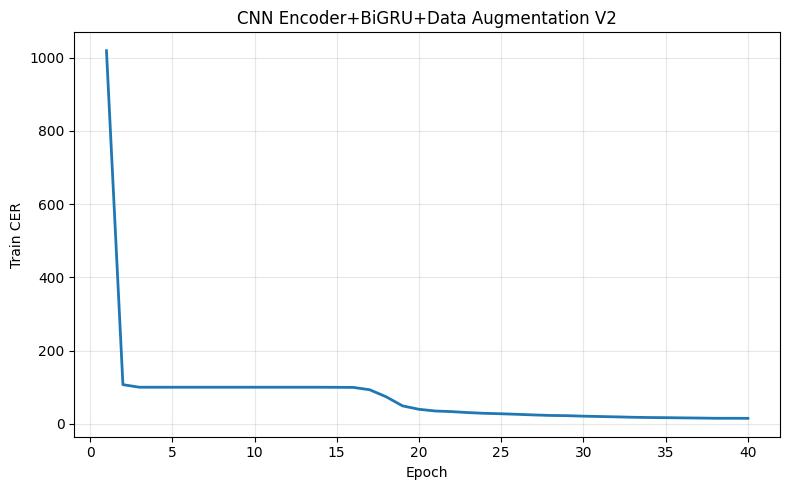

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Path to the CSV exported from TensorBoard
# csv_path = "/home/aki.hj/emg2qwerty/baseline_trainCER.csv"
csv_path = "/home/aki.hj/emg2qwerty/bestarchitecture_trainCER.csv"

df = pd.read_csv(csv_path)
print(df.columns)

epochs = range(1, len(df) + 1)
cer = df["Value"]

plt.figure(figsize=(8, 5))
plt.plot(epochs, cer, linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Train CER")
# plt.title("CNN Encoder+TDSConv (Baseline)")
plt.title("CNN Encoder+BiGRU+Data Augmentation V2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()